In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
!pip install chardet

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import chardet

In [4]:
with open('C:/Users/Мария/Downloads/tbank_summer2026_product_analyst.csv', 'rb') as f:
    print(chardet.detect(f.read(10000))['encoding'])

IBM866


In [5]:
df = pd.read_csv('C:/Users/Мария/Downloads/tbank_summer2026_product_analyst.csv', encoding='IBM866', sep=';')

In [6]:
df = df.iloc[:-1] # убираем строку с суммой - она не нужна

In [7]:
for col in df.columns[2:]: # приводим в порядок данные
    df[col] = df[col].astype(float)

In [8]:
week_df = df
week_df.drop(columns='Дата') # убираем даты, тк далее датафрейм будет группироваться по неделям

,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,Неделя 1,206.0,130.0,91.0,70.0,57.0,51.0
1,Неделя 1,216.0,138.0,98.0,73.0,55.0,48.0
2,Неделя 1,181.0,117.0,86.0,69.0,52.0,46.0
3,Неделя 1,212.0,134.0,101.0,83.0,64.0,54.0
4,Неделя 1,218.0,143.0,97.0,73.0,60.0,53.0
5,Неделя 1,212.0,146.0,106.0,90.0,70.0,62.0
6,Неделя 1,213.0,145.0,110.0,89.0,72.0,60.0
7,Неделя 2,189.0,123.0,83.0,64.0,48.0,41.0
8,Неделя 2,205.0,135.0,95.0,73.0,56.0,52.0
9,Неделя 2,206.0,140.0,96.0,79.0,59.0,51.0


In [9]:
week_df.groupby('Неделя').mean()

,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
Неделя,,,,,,
Неделя 1,208.285714,136.142857,98.428571,78.142857,61.428571,53.428571
Неделя 2,202.142857,133.285714,94.428571,74.571429,58.714286,52.571429
Неделя 3,204.714286,139.000000,103.000000,83.000000,62.857143,54.142857
Неделя 4,201.000000,136.571429,98.285714,78.428571,59.285714,52.000000
Неделя 5,204.714286,136.571429,99.428571,79.428571,62.857143,54.714286
Неделя 6,193.857143,131.714286,93.285714,73.714286,58.714286,53.285714
Неделя 7,218.000000,145.857143,72.000000,60.571429,48.000000,40.428571
Неделя 8,218.285714,147.285714,74.142857,60.142857,47.857143,42.714286


По сгруппированному датафрейму можно понять, что проблема находится на последних двух неделях между этапами "Регистрации" и 
"Открыли поиск"

In [10]:
week_df['CR_Total'] = (week_df['Первая поездка'] / week_df['Установки']) * 100 # Конверсия Установка - Первая поездка
week_df['CR_Search'] = (week_df['Открыли поиск'] / week_df['Регистрации']) * 100 # Конверсия проблемы: Регистрация - Поиск

In [11]:
week_df = week_df.groupby('Неделя').mean()
print(week_df)

           Установки  Регистрации  Открыли поиск  Просмотрели авто  \
Неделя                                                               
Неделя 1  208.285714   136.142857      98.428571         78.142857   
Неделя 2  202.142857   133.285714      94.428571         74.571429   
Неделя 3  204.714286   139.000000     103.000000         83.000000   
Неделя 4  201.000000   136.571429      98.285714         78.428571   
Неделя 5  204.714286   136.571429      99.428571         79.428571   
Неделя 6  193.857143   131.714286      93.285714         73.714286   
Неделя 7  218.000000   145.857143      72.000000         60.571429   
Неделя 8  218.285714   147.285714      74.142857         60.142857   

          Забронировали  Первая поездка   CR_Total  CR_Search  
Неделя                                                         
Неделя 1      61.428571       53.428571  25.655970  72.312697  
Неделя 2      58.714286       52.571429  25.887491  70.775379  
Неделя 3      62.857143       54.142857  26

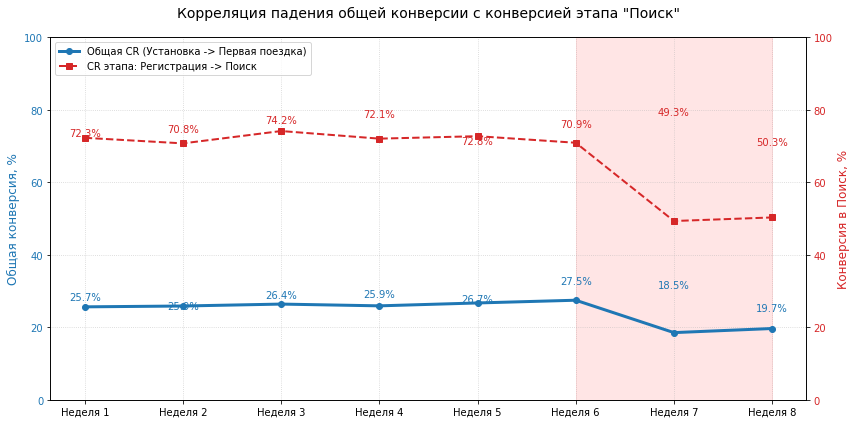

In [12]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Общая конверсия
line1, = ax1.plot(week_df.index, week_df['CR_Total'], marker='o', color='#1f77b4', 
                 linewidth=3, label='Общая CR (Установка -> Первая поездка)')
ax1.set_ylabel('Общая конверсия, %', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_ylim(0, 100)

for i, txt in enumerate(week_df['CR_Total']): # Проценты
    ax1.annotate(f'{txt:.1f}%', 
                 (df.index[i], df['CR_Total'][i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 color='#1f77b4')

# Конверсия в поиск
ax2 = ax1.twinx()

line2, = ax2.plot(week_df.index, week_df['CR_Search'], marker='s', color='#d62728', 
                 linestyle='--', linewidth=2, label='CR этапа: Регистрация -> Поиск')

ax2.set_ylabel('Конверсия в Поиск, %', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(0, 100)

for i, txt in enumerate(week_df['CR_Search']): # Проценты
    ax2.annotate(f'{txt:.1f}%',
                 (df.index[i], df['CR_Search'][i]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center',
                 color='#d62728')

ax1.axvspan(5, 7, color='red', alpha=0.1, label='Период падения') # Подсветка зоны проблемы (7-8 недели)

plt.title('Корреляция падения общей конверсии с конверсией этапа "Поиск"', fontsize=14, pad=20)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(handles=[line1, line2], loc='upper left')

plt.tight_layout()
plt.show()


1. Удержание старых пользователей не изменилось -> новые пользователи испытывают проблемы и уходят
2. Проблема находится между этапами "Регистрации" и "Открыли поиск" -> новым пользователям сложно разобраться с работой поиска

Нужно проверять работу поиска, в частности, проверить, насколько внешнему пользователю понятен интерфейс поисковика, поскольку у старых пользователей проблем нет.